First 5 Rows
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0        

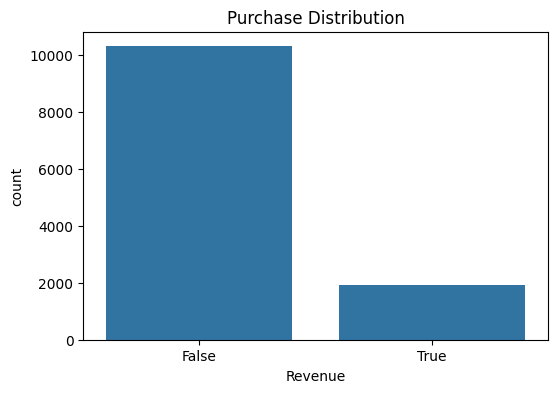

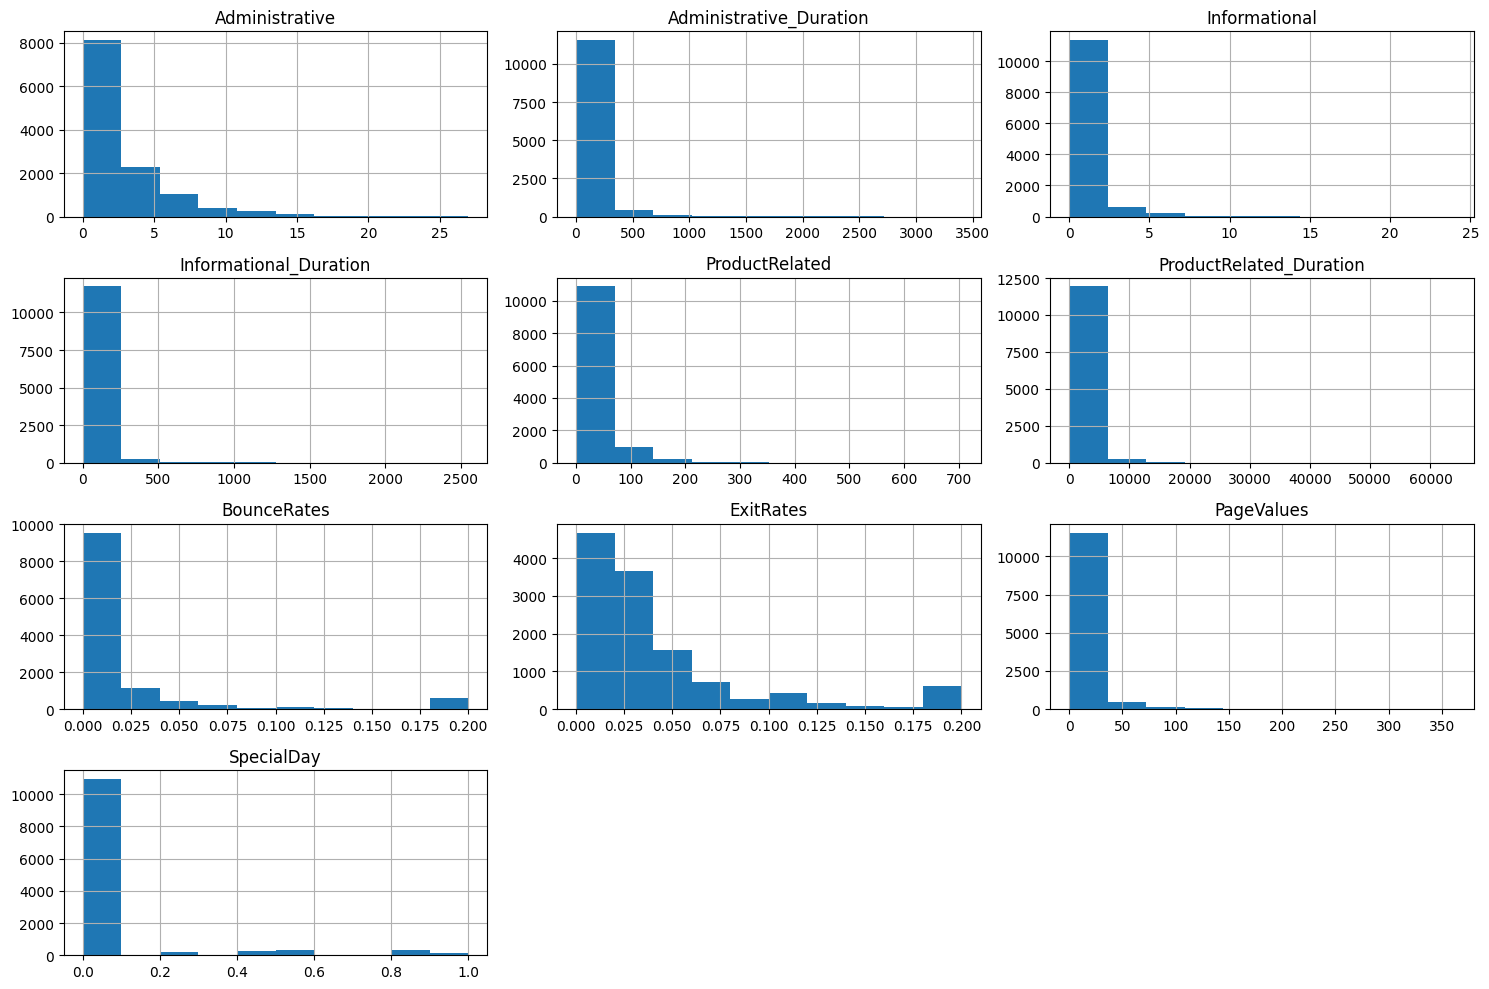

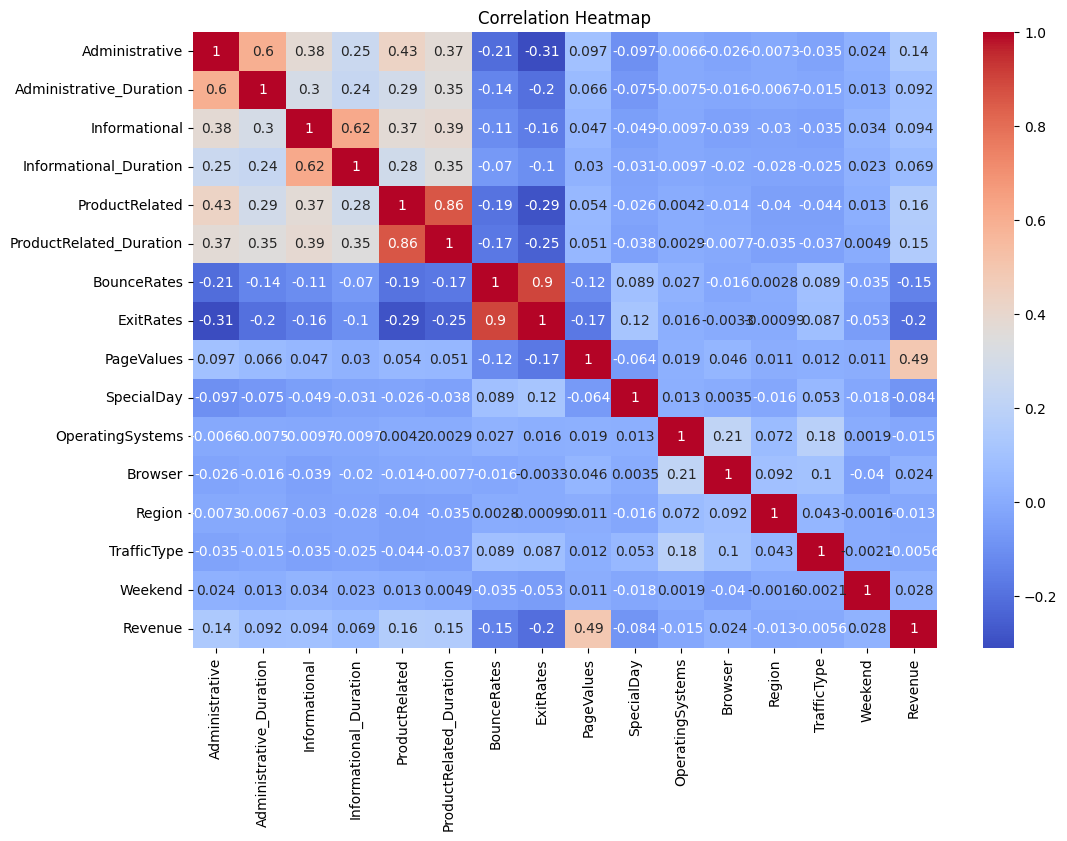

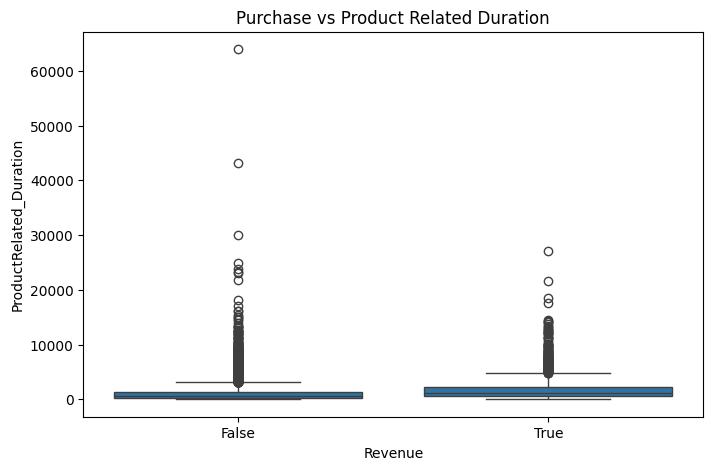

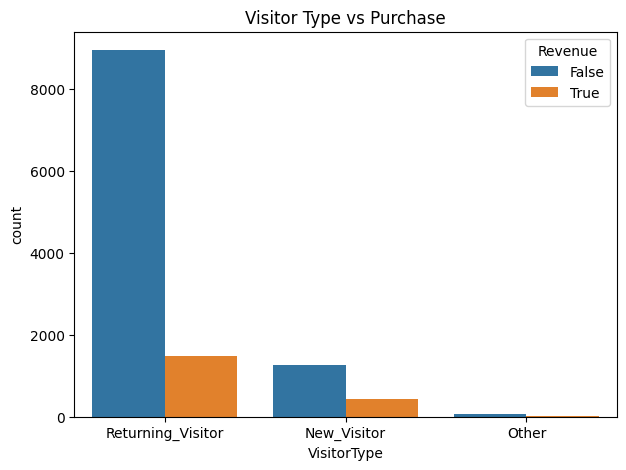

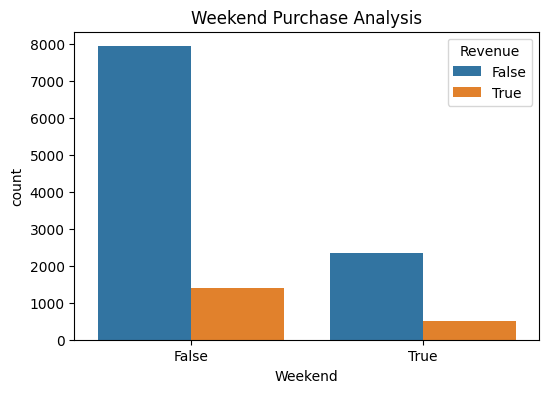


Features Shape: (12205, 17)
Target Shape: (12205,)

Preprocessed Dataset
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay  Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0      2    

In [1]:
# ==========================================
# ONLINE SHOPPERS INTENTION - EDA & PREPROCESSING
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# ------------------------------------------
# LOAD DATASET
# ------------------------------------------

url = "https://huggingface.co/api/resolve-cache/datasets/ScortonAI/online-shoppers-intention/e0d766576fded94871d9f3b8cdc3de36b7d66d09/online_shoppers_intention.csv?%2Fdatasets%2FScortonAI%2Fonline-shoppers-intention%2Fresolve%2Fmain%2Fonline_shoppers_intention.csv=&etag=%2250685200654dbfe454500e4ffb9678d861761005%22"

df = pd.read_csv(url)

# ------------------------------------------
# BASIC INFORMATION
# ------------------------------------------

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

# ------------------------------------------
# CHECK MISSING VALUES
# ------------------------------------------

print("\nMissing Values")
print(df.isnull().sum())

# ------------------------------------------
# CHECK DUPLICATES
# ------------------------------------------

print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates if needed
df = df.drop_duplicates()

# ------------------------------------------
# TARGET VARIABLE DISTRIBUTION
# ------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='Revenue', data=df)
plt.title("Purchase Distribution")
plt.show()

# ------------------------------------------
# NUMERICAL FEATURE DISTRIBUTION
# ------------------------------------------

numerical_cols = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

df[numerical_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

# ------------------------------------------
# CORRELATION HEATMAP
# ------------------------------------------

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# ------------------------------------------
# PURCHASE VS PRODUCT RELATED PAGES
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Revenue',
    y='ProductRelated_Duration',
    data=df
)

plt.title("Purchase vs Product Related Duration")
plt.show()

# ------------------------------------------
# VISITOR TYPE ANALYSIS
# ------------------------------------------

plt.figure(figsize=(7,5))

sns.countplot(
    x='VisitorType',
    hue='Revenue',
    data=df
)

plt.title("Visitor Type vs Purchase")
plt.show()

# ------------------------------------------
# WEEKEND PURCHASE ANALYSIS
# ------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(
    x='Weekend',
    hue='Revenue',
    data=df
)

plt.title("Weekend Purchase Analysis")
plt.show()

# ------------------------------------------
# PREPROCESSING
# ------------------------------------------

# Copy dataset
data = df.copy()

# ------------------------------------------
# ENCODE CATEGORICAL COLUMNS
# ------------------------------------------

label_encoder = LabelEncoder()

categorical_cols = [
    'Month',
    'VisitorType',
    'Weekend',
    'Revenue'
]

for col in categorical_cols:
    data[col] = label_encoder.fit_transform(data[col])

# ------------------------------------------
# FEATURES & TARGET
# ------------------------------------------

X = data.drop('Revenue', axis=1)
y = data['Revenue']

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

# ------------------------------------------
# FINAL PREPROCESSED DATA
# ------------------------------------------

print("\nPreprocessed Dataset")
print(data.head())

# ------------------------------------------
# SAVE CLEAN DATASET
# ------------------------------------------

data.to_csv("cleaned_online_shoppers_data.csv", index=False)

print("\nCleaned dataset saved successfully!")

Missing Values:

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Training Shape: (9764, 17)
Testing Shape: (2441, 17)

Model Training Completed!

Accuracy Score:
0.876689881196231

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.92      2059
           1       0.58      0.77      0.66       382

    accuracy                           0.88      2441
   macro avg       0.77      0.84      0.79      2441
weighted avg       0.90      0.88   

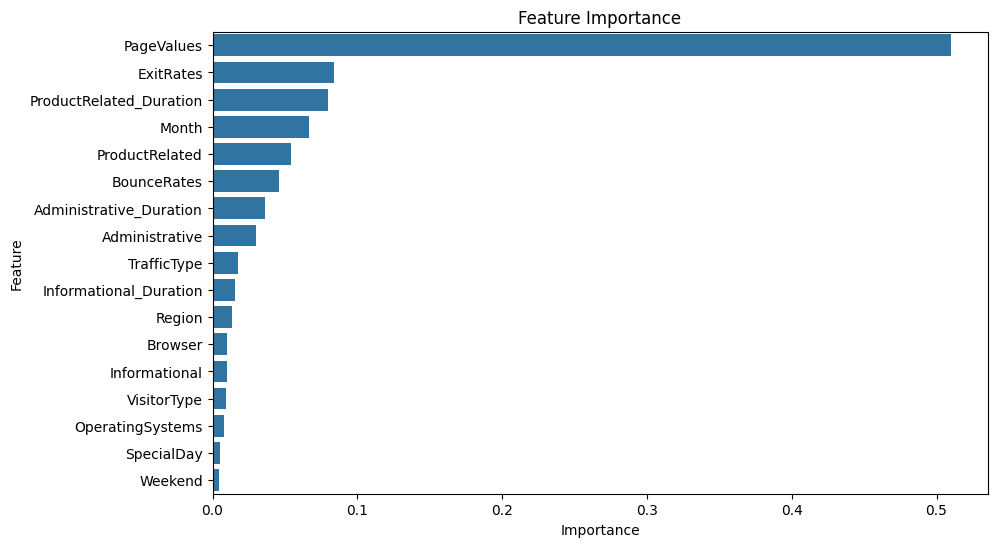

11757    0
7022     0
7281     0
11373    0
4799     0
9976     0
8189     0
6727     0
10316    0
10325    0
9203     0
5784     0
8859     0
11665    0
9248     0
2272     0
1986     0
2310     0
2909     0
7387     0
1835     0
10262    1
1058     0
3986     0
10266    0
10265    0
7857     1
1920     0
8315     0
8121     0
6222     1
5576     0
5442     0
8727     1
8600     0
910      0
7249     0
2815     0
6774     0
12318    0
7186     0
11769    0
3911     0
8124     0
8060     0
12054    0
7105     0
5889     1
9911     0
6190     0
Name: Revenue, dtype: int64

Customer Session 11757
Customer is NOT likely to purchase with prediction value 0

Customer Session 7022
Customer is NOT likely to purchase with prediction value 0

Customer Session 7281
Customer is NOT likely to purchase with prediction value 0

Customer Session 11373
Customer is NOT likely to purchase with prediction value 0

Customer Session 4799
Customer is NOT likely to purchase with prediction value 0

Customer 

In [15]:
# ==========================================
# ONLINE SHOPPERS PURCHASE PREDICTION
# BEST MODEL BUILDING & TRAINING
# ==========================================

# ------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------
# LOAD DATASET
# ------------------------------------------

url = "https://huggingface.co/api/resolve-cache/datasets/ScortonAI/online-shoppers-intention/e0d766576fded94871d9f3b8cdc3de36b7d66d09/online_shoppers_intention.csv?%2Fdatasets%2FScortonAI%2Fonline-shoppers-intention%2Fresolve%2Fmain%2Fonline_shoppers_intention.csv=&etag=%2250685200654dbfe454500e4ffb9678d861761005%22"

df = pd.read_csv(url)

# ------------------------------------------
# BASIC DATA CLEANING
# ------------------------------------------

# Remove duplicate rows
df = df.drop_duplicates()

# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())

# ------------------------------------------
# ENCODE CATEGORICAL COLUMNS
# ------------------------------------------

label_encoder = LabelEncoder()

categorical_cols = [
    'Month',
    'VisitorType',
    'Weekend',
    'Revenue'
]

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

# ------------------------------------------
# FEATURES & TARGET
# ------------------------------------------

X = df.drop('Revenue', axis=1)
y = df['Revenue']

# ------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ------------------------------------------
# BUILD RANDOM FOREST MODEL
# ------------------------------------------

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

# ------------------------------------------
# TRAIN MODEL
# ------------------------------------------

model.fit(X_train, y_train)

print("\nModel Training Completed!")

# ------------------------------------------
# PREDICTIONS
# ------------------------------------------

y_pred = model.predict(X_test)

# ------------------------------------------
# MODEL EVALUATION
# ------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ------------------------------------------
# FEATURE IMPORTANCE
# ------------------------------------------

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:\n")
print(importance)

# ------------------------------------------
# TOP FEATURES VISUALIZATION
# ------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

# ------------------------------------------
# SAMPLE PREDICTION
# ------------------------------------------

# Predict first 20 customers/sessions

samples = X_test.iloc[0:50]

predictions = model.predict(samples)
sample_indices = X_test.iloc[0:50].index
print(df.loc[sample_indices, 'Revenue'])

# Loop through predictions
for i, pred in enumerate(predictions):

    print(f"\nCustomer Session {samples.index[i]}")

    if pred == 1:
        print("Customer is likely to PURCHASE" ,"with prediction value" , pred)
    else:
        print("Customer is NOT likely to purchase", "with prediction value" , pred)



# Print Actual vs Predicted
actual_values = y_test.iloc[0:50].values
for i in range(len(predictions)):

    print(f"\nCustomer Session Index: {samples.index[i]}")

    print("Actual Value    :", actual_values[i])

    print("Predicted Value :", predictions[i])

    # Compare result
    if actual_values[i] == predictions[i]:
        print("Result          : MATCHED")
    else:
        print("Result          : MISMATCHED")

# Calculate accuracy for the 50 customers

actual_values = y_test.iloc[0:50].values

matched = 0
mismatched = 0

for i in range(len(predictions)):
    if actual_values[i] == predictions[i]:
        matched += 1
    else:
        mismatched += 1

accuracy = (matched / len(predictions)) * 100
mismatch = (mismatched / len(predictions)) * 100

print("\n====================")
print("FINAL SUMMARY (50 CUSTOMERS)")
print("====================")

print("Total Customers :", len(predictions))
print("Matched         :", matched)
print("Mismatched      :", mismatched)

print(f"\nAccuracy  : {accuracy:.2f}%")
print(f"Mismatch  : {mismatch:.2f}%")